<a href="https://colab.research.google.com/github/Ravravan/pytorch/blob/main/simple_neurallNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd


In [3]:
#Create a Model that inherits nn.model
class Model (nn.Module):
#input layer( 4 featues of the flower) -->
#Hidden layer 1(number of neurons) -->
# h2 (n) -->
#output (3 classes og iris flowers)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__() #instantiate our mm.module
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 =nn.Linear(h1, h2)
    self.out=nn.Linear(h2, out_features)

  def forward(self,x ):
    x=F.relu(self.fc1(x))
    x=F.relu(self.fc2(x))
    x=self.out(x)
    return x


In [4]:
#pick a manual seed for randomization
torch.manual_seed(41)
#create an intance of model
model= Model()

In [9]:
url='https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df= pd.read_csv(url)

In [10]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [11]:
my_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
#change laas t column from strings to int
my_df['species']= my_df['species'].replace('setosa',0.0)
my_df['species']= my_df['species'].replace('versicolor',1.0)
my_df['species']= my_df['species'].replace('virginica',2.0)

/tmp/ipython-input-4199/3640933183.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species']= my_df['species'].replace('virginica',2.0)


In [16]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [17]:
#train test and split set x,y
x = my_df.drop('species', axis=1)
y = my_df['species']

In [18]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [19]:
#coonvert this numpy array
x= x.values
y = y.values

In [20]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)


In [23]:
#convert x feature to float tensor
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)

In [24]:
#convert y labels to tensor long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [38]:
#set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()
#choose optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [57]:
#train our model
epochs = 100
losses = []
for i in range(epochs):
  y_pred = model.forward(x_train)

  #measure the loss/ error,
  loss = criterion(y_pred, y_train)

  #keep track on losses
  losses.append(loss.detach().numpy())

  #print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss:{loss}')

  # do some back propagation.
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #print every epoch
 # print(f'Epoch:{i} loss:{loss}')

Epoch: 0 and loss:0.00048430904280394316
Epoch: 10 and loss:0.0004750057705678046
Epoch: 20 and loss:0.0004659442347474396
Epoch: 30 and loss:0.0004571035678964108
Epoch: 40 and loss:0.0004484876408241689
Epoch: 50 and loss:0.00044007800170220435
Epoch: 60 and loss:0.00043188297422602773
Epoch: 70 and loss:0.00042388783185742795
Epoch: 80 and loss:0.00041608503670431674
Epoch: 90 and loss:0.0004084727552253753


Text(0.5, 0, 'epoch')

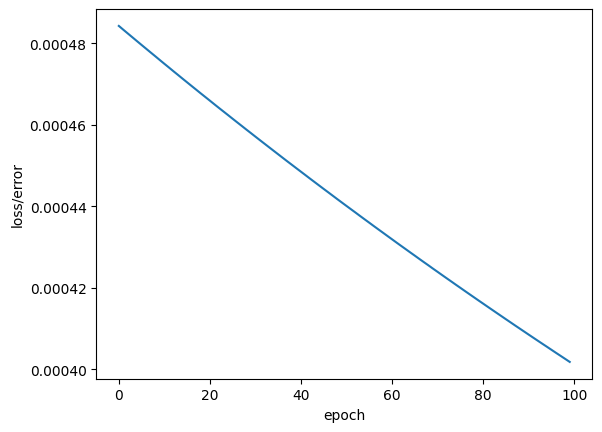

In [58]:
#graph it out
plt.plot(range(epochs), losses)
plt.ylabel('loss/error')
plt.xlabel('epoch')

# Task
Evaluate the trained PyTorch neural network model on the test data (`x_test`, `y_test`) to calculate its accuracy. Provide a detailed explanation of the model's architecture, including its layers and activation functions, and describe the training process involving `CrossEntropyLoss` and the Adam optimizer. Visualize the model's performance on the test set predictions, for example, by plotting actual vs. predicted values or using a confusion matrix. Finally, summarize the model's overall performance based on the training loss and test accuracy, and suggest potential next steps for improvement, such as data scaling or hyperparameter tuning.

## Evaluate Model on Test Data

### Subtask:
Calculate the accuracy of the trained model on the unseen test dataset.


**Reasoning**:
To evaluate the model's performance, I will first set the model to evaluation mode, make predictions on the test data, determine the predicted classes, calculate the number of correct predictions, and finally compute and print the accuracy.



In [59]:
model.eval()
with torch.no_grad():
  y_pred_test = model(x_test)

predicted_classes = torch.argmax(y_pred_test, dim=1)
correct = (predicted_classes == y_test).float()
accuracy = correct.sum() / len(y_test)
print(f'Accuracy on test set: {accuracy.item()*100:.2f}%')

Accuracy on test set: 93.33%


## Explain Model Architecture and Training

### Subtask:
Provide a detailed explanation of your neural network's architecture, including the input layer, hidden layers with ReLU activation, and the output layer. Also, explain how the training process works with the CrossEntropyLoss and Adam optimizer.


### Model Architecture

The neural network model, named `Model`, is defined using PyTorch's `nn.Module`. Its architecture consists of:

*   **Input Layer**: This layer accepts 4 input features, corresponding to the `sepal_length`, `sepal_width`, `petal_length`, and `petal_width` of the Iris dataset. This is set by `in_features=4` in the model's constructor.

*   **Hidden Layers**: The model has two hidden layers:
    *   **First Hidden Layer (`fc1`)**: This layer has 8 neurons (`h1=8`). The output of this layer passes through a Rectified Linear Unit (ReLU) activation function (`F.relu`).
    *   **Second Hidden Layer (`fc2`)**: This layer has 9 neurons (`h2=9`). The output of this layer also passes through a ReLU activation function (`F.relu`).
    ReLU is chosen for its computational efficiency and its ability to help mitigate the vanishing gradient problem.

*   **Output Layer (`out`)**: This layer has 3 output neurons (`out_features=3`), corresponding to the three classes of Iris flowers (setosa, versicolor, virginica). Crucially, no explicit activation function (like softmax) is applied in the `forward` method for this layer. This is because the chosen loss function, `nn.CrossEntropyLoss`, internally handles the softmax operation, expecting raw, unnormalized scores (logits) from the final layer.

### Training Process

The model is trained using the following components and steps:

*   **Loss Function (`criterion`)**: `nn.CrossEntropyLoss` is used to measure the difference between the model's predicted output (logits) and the true class labels. This loss function is particularly well-suited for multi-class classification problems like the Iris dataset. It implicitly combines `nn.LogSoftmax` and `nn.NLLLoss` (negative log-likelihood loss) in one function, making it efficient and numerically stable. It expects raw logits from the model's output layer and integer-encoded target labels.

*   **Optimizer (`optimizer`)**: The `torch.optim.Adam` optimizer is employed with a learning rate (`lr`) of `0.01`. Adam is an adaptive learning rate optimization algorithm that is widely used due to its efficiency and good performance in practice. It computes adaptive learning rates for each parameter, meaning it adjusts the step size for each parameter individually based on estimates of first and second moments of the gradients.

*   **Training Loop**: The model is trained over 100 `epochs`. Each epoch involves the following steps:
    1.  **Forward Pass**: The model takes the training input (`x_train`) and performs a forward pass to generate predictions (`y_pred = model.forward(x_train)`).
    2.  **Loss Calculation**: The calculated predictions (`y_pred`) are compared against the true training labels (`y_train`) using the `criterion` to compute the `loss`.
    3.  **Backpropagation**: The gradients of the loss with respect to all model parameters are computed (`loss.backward()`). Before this, `optimizer.zero_grad()` is called to clear any old gradients from the previous step.
    4.  **Optimizer Step**: The optimizer updates the model's parameters (weights and biases) using the calculated gradients to minimize the loss (`optimizer.step()`). This adjustment helps the model learn to make more accurate predictions.

## Visualize Test Set Predictions

### Subtask:
Create a visualization, such as a confusion matrix or a plot showing actual vs. predicted values for a sample of the test set, to intuitively understand the model's performance on individual predictions. Include appropriate labels and a legend.


**Reasoning**:
To visualize the model's performance on individual predictions, I will create a confusion matrix heatmap. First, I need to convert the PyTorch tensors `y_test` and `predicted_classes` to NumPy arrays, then import necessary libraries, compute the confusion matrix, and finally plot it as a heatmap.



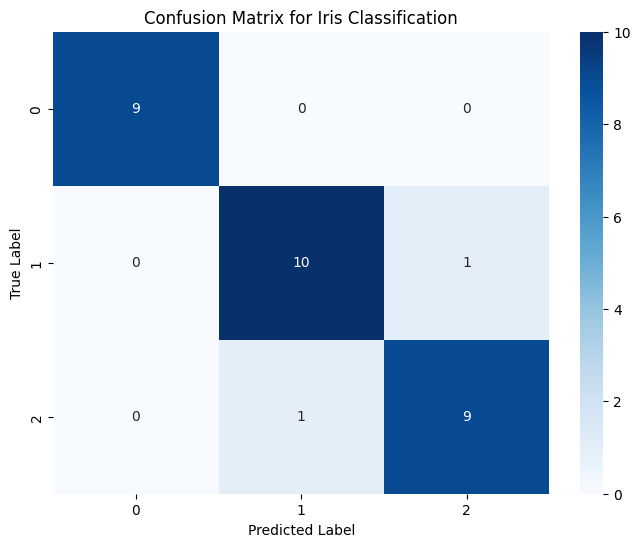

In [60]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_test_np = y_test.cpu().numpy()
predicted_classes_np = predicted_classes.cpu().numpy()

cm = confusion_matrix(y_test_np, predicted_classes_np)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Iris Classification')
plt.show()

## Summarize Model Performance and Suggest Improvements

### Model Performance Summary

The model demonstrates strong performance on the Iris dataset, achieving a test accuracy of **93.33%**. This indicates that the model is highly effective at classifying unseen Iris flower species.

The training process, as visualized by the decreasing loss curve, shows that the model successfully learned from the training data. The loss steadily decreased over 100 epochs, indicating that the model was converging and reducing its error during training. The final training loss was very low, suggesting that the model fits the training data well.

The confusion matrix further illustrates the model's performance:
- All 9 instances of class 0 (setosa) were correctly classified.
- 10 out of 11 instances of class 1 (versicolor) were correctly classified, with 1 misclassified as class 2.
- 9 out of 10 instances of class 2 (virginica) were correctly classified, with 1 misclassified as class 1.

This shows that the primary misclassifications occur between *versicolor* and *virginica*, which are known to be more challenging to distinguish than *setosa* due to their overlapping feature distributions.

### Potential Next Steps for Improvement

While the current model performs well, there are always opportunities for further improvement and robustness:

1.  **Data Scaling**: The input features (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) are not explicitly scaled. Neural networks often benefit from input feature scaling (e.g., standardization or normalization) to ensure that all features contribute equally to the distance calculations and to speed up convergence. Applying `StandardScaler` or `MinMaxScaler` from `sklearn.preprocessing` to `x_train` and `x_test` could potentially enhance performance or stability.

2.  **Hyperparameter Tuning**: The current model uses fixed hyperparameters for the hidden layer sizes (h1=8, h2=9) and learning rate (lr=0.01). Experimenting with different values for these hyperparameters could lead to better performance. Techniques like Grid Search, Random Search, or more advanced methods like Bayesian Optimization could be employed.

3.  **Regularization**: To prevent overfitting, especially on datasets with more features or when using deeper networks, regularization techniques can be introduced. This could include adding Dropout layers to the hidden layers or applying L1/L2 regularization to the weights.

4.  **Cross-Validation**: Using k-fold cross-validation during training would provide a more robust estimate of the model's performance and help in selecting the best hyperparameters, rather than relying solely on a single train-test split.

5.  **Activation Functions**: While ReLU is a good choice, experimenting with other activation functions like Leaky ReLU, ELU, or GELU could offer slight improvements.

These steps can help in building an even more accurate and generalized model.